# Stock Price Forecast with TimeSeriesTransformerForPrediction

In [1]:
import pandas as pd
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from transformers import TimeSeriesTransformerConfig, TimeSeriesTransformerForPrediction

## Baseline Models

In [2]:
aapl = pd.read_csv("AAPL.csv")
aapl.columns = ["Date", "Close/Last", "Volume", "Open", "High", "Low"]
price_cols = ["Close/Last", "Open", "High", "Low"]
for col in price_cols:
     aapl[col] = aapl[col].replace('[\$,]', '', regex=True).astype(float)
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date').reset_index(drop=True)
aapl.head()

,Date,Close/Last,Volume,Open,High,Low
0,2020-04-03,60.3525,129880080,60.700,61.4250,59.7435
1,2020-04-06,65.6175,201820280,62.725,65.7775,62.3450
2,2020-04-07,64.8575,202887320,67.700,67.9250,64.7500
3,2020-04-08,66.5175,168895280,65.685,66.8425,65.3075
4,2020-04-09,66.9975,162116480,67.175,67.5175,66.1750


### Simple Moving Average

In [3]:
aapl['SMA10'] = aapl['Close/Last'].rolling(window=10).mean().shift(1)

sma_aapl_eval = aapl.dropna(subset=['SMA10', 'Close/Last'])

sma_mae = mean_absolute_error(sma_aapl_eval['Close/Last'], sma_aapl_eval['SMA10'])
sma_mse = mean_squared_error(sma_aapl_eval['Close/Last'], sma_aapl_eval['SMA10'])
sma_rmse = sma_mse ** 0.5

print("SMA10 MAE:", sma_mae)
print("SMA10 RMSE:", sma_rmse)

sma_actual_diff = sma_aapl_eval['Close/Last'].diff().fillna(0)
sma_pred_diff = sma_aapl_eval['SMA10'].diff().fillna(0)
sma_directional_match = (np.sign(sma_actual_diff) == np.sign(sma_pred_diff)).astype(int)
sma_directional_accuracy = sma_directional_match.sum() / len(sma_directional_match)
print("SMA10 Directional Accuracy:", sma_directional_accuracy)

SMA10 MAE: 4.341093699839487
SMA10 RMSE: 5.454213498028166
SMA10 Directional Accuracy: 0.5168539325842697


### Multilayer Perceptron (MLP)¶

In [4]:
X = aapl[['Open', 'High', 'Low', 'Close/Last']].shift(1).dropna().values
y = aapl['Close/Last'].shift(-1).dropna().values.reshape(-1, 1)  # Next day's Close

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y).flatten()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, shuffle=False)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.hidden_layer1 = nn.Linear(4, 64)  # Input features: 4 (OHLC)
        self.hidden_layer2 = nn.Linear(64, 32) 
        self.output_layer = nn.Linear(32, 1)  # Output: 1 (next day's Close)

    def forward(self, x):
        x = torch.relu(self.hidden_layer1(x))  # Apply ReLU activation
        x = torch.relu(self.hidden_layer2(x))
        x = self.output_layer(x)
        return x

model = MLP()

criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model
epochs = 100
for epoch in range(epochs):
    model.train()
    
    # Forward pass
    y_pred = model(X_train_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_train_tensor)
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    y_test_pred = model(X_test_tensor)

y_test_pred_np = y_scaler.inverse_transform(y_test_pred.numpy())
y_test_true_np = y_scaler.inverse_transform(y_test_tensor.numpy())

mlp_mae = mean_absolute_error(y_test_true_np, y_test_pred_np)
mlp_mse = mean_squared_error(y_test_true_np, y_test_pred_np)
mlp_rmse = mlp_mse ** 0.5

print("MLP MAE:", mlp_mae)
print("MLP RMSE:", mlp_rmse)

# Directional Accuracy
mlp_actual_np = y_test_tensor.numpy().flatten()
mlp_pred_np = y_test_pred.numpy().flatten()
mlp_actual_diff = np.diff(mlp_actual_np)
mlp_pred_diff = np.diff(mlp_pred_np)

mlp_directional_match = (np.sign(mlp_actual_diff) == np.sign(mlp_pred_diff)).astype(int)
mlp_directional_accuracy = mlp_directional_match.sum() / len(mlp_directional_match)

print("MLP Directional Accuracy:", mlp_directional_accuracy)

Epoch [10/100], Loss: 0.3345
Epoch [20/100], Loss: 0.1161
Epoch [30/100], Loss: 0.0227
Epoch [40/100], Loss: 0.0127
Epoch [50/100], Loss: 0.0101
Epoch [60/100], Loss: 0.0083
Epoch [70/100], Loss: 0.0069
Epoch [80/100], Loss: 0.0063
Epoch [90/100], Loss: 0.0057
Epoch [100/100], Loss: 0.0054
MLP MAE: 14.250110626220703
MLP RMSE: 16.022914690093547
MLP Directional Accuracy: 0.544


# TimeSeriesTransformerForPrediction Model

### Helper Functions

In [5]:
def compute_RSI(series, window=14):
    delta = series.diff()
    up, down = delta.clip(lower=0), -delta.clip(upper=0)
    ma_up   = up.rolling(window).mean()
    ma_down = down.rolling(window).mean()
    rs = ma_up / ma_down
    return 100 - (100 / (1 + rs))

def compute_MACD(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast).mean()
    ema_slow = series.ewm(span=slow).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal).mean()
    hist = macd - signal_line
    return macd, signal_line, hist

def compute_ATR(df, window=14):
    h_l = df['High'] - df['Low']
    h_c = (df['High'] - df['Close'].shift()).abs()
    l_c = (df['Low']  - df['Close'].shift()).abs()
    tr  = pd.concat([h_l, h_c, l_c], axis=1).max(axis=1)
    return tr.rolling(window).mean()

def compute_Bollinger(df, window=20, n_std=2):
    ma = df['Close'].rolling(window).mean()
    std = df['Close'].rolling(window).std()
    return {'upper': ma + n_std*std, 'lower': ma - n_std*std}

def add_calendar_cols(df):
    df['month']        = df['Date'].dt.month
    df['day_of_week']  = df['Date'].dt.dayofweek
    df['day_of_year']  = df['Date'].dt.dayofyear
    df['year']         = df['Date'].dt.year
    # cyclic encodings
    df['year_sin']  = np.sin(2*np.pi*df['day_of_year']/365.25)
    df['year_cos']  = np.cos(2*np.pi*df['day_of_year']/365.25)
    df['week_sin']  = np.sin(2*np.pi*df['day_of_week']/7)
    df['week_cos']  = np.cos(2*np.pi*df['day_of_week']/7)
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    return df

### Load Data & Features

In [6]:
aapl = pd.read_csv("AAPL.csv")
aapl = aapl.rename(columns={'Close/Last':'Close'})
aapl.columns = ['Date','Close','Volume','Open','High','Low']
for col in ['Close','Open','High','Low']:
    aapl[col] = aapl[col].str.replace('$','').astype(float)

aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl.sort_values('Date', inplace=True, ignore_index=True)

# technical indicators
aapl['RSI'] = compute_RSI(aapl['Close'])
macd, sig, hist = compute_MACD(aapl['Close'])
macd_line, sig_line, macd_hist = compute_MACD(aapl["Close"])

macd_df = (
    pd.concat([macd_line, sig_line, macd_hist], axis=1)
    .set_axis(["MACD", "MACD_signal", "MACD_hist"], axis=1)
)

# add the three columns in one shot
aapl = pd.concat([aapl, macd_df], axis=1)
aapl['ATR'] = compute_ATR(aapl)
bb = compute_Bollinger(aapl)
aapl[['BB_upper','BB_lower']] = pd.concat(bb, axis=1)
aapl['Volume_change'] = aapl['Volume'].pct_change()

# moving averages
for w in [5,10,20,50,200]:
    aapl[f"MA{w}"] = aapl['Close'].rolling(w).mean()

# calendar features
aapl = add_calendar_cols(aapl)

# drop rows with NaNs created by rolling / pct_change
aapl.dropna(inplace=True), aapl.reset_index(drop=True, inplace=True)

(None, None)

### Prepare Sliding Windows

In [7]:
context_len, pred_len, max_lag = 30, 5, 30
input_len   = context_len + max_lag

price_cols = ['Open','High','Low','Close']
feat_cols  = (
    ['year_sin','year_cos','week_sin','week_cos',
     'month_sin','month_cos','day_of_week','month','day_of_year','year']
    + ['RSI','MACD','MACD_signal','MACD_hist','ATR',
       'BB_upper','BB_lower','Volume_change']
    + [f"MA{w}" for w in [5,10,20,50,200]]
)                                               # 10 + 8 + 5 = 23 extra feats

P = aapl[price_cols].values.astype(np.float32)
F = aapl[feat_cols ].values.astype(np.float32)

N = len(aapl) - (input_len + pred_len) + 1
past_vals   = np.stack([P[i:i+input_len]                 for i in range(N)])       # (N,60,4)
past_feats  = np.stack([F[i:i+input_len]                 for i in range(N)])       # (N,60,23)
future_vals = np.stack([P[i+input_len:i+input_len+pred_len] for i in range(N)])    # (N,5,4)
future_feats= np.stack([F[i+input_len:i+input_len+pred_len] for i in range(N)])    # (N,5,23)

# tensors
t_past_v  = torch.tensor(past_vals  )
t_past_f  = torch.tensor(past_feats )
t_future_v= torch.tensor(future_vals)
t_future_f= torch.tensor(future_feats)
mask      = torch.ones((N, context_len, 4), dtype=torch.bool)

### Train and Validation/Test Splits & Loaders

In [8]:
split = int(0.8*N)
train_ds = TensorDataset(t_past_v[:split], t_past_f[:split], mask[:split],
                         t_future_v[:split], t_future_f[:split])
val_ds   = TensorDataset(t_past_v[split:], t_past_f[split:], mask[split:],
                         t_future_v[split:], t_future_f[split:])

batch=32
train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False)

### Model Configuration

In [9]:
cfg = TimeSeriesTransformerConfig(
        input_size          = 4,
        num_time_features   = past_feats.shape[-1],   # 23
        context_length      = context_len,
        prediction_length   = pred_len,
        lags_sequence       = [1,7,30],
        scaling             = "std",
        d_model             = 64,
        encoder_layers      = 4,
        decoder_layers      = 4,
        num_parallel_samples= 100,
)
model = TimeSeriesTransformerForPrediction(cfg)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-3)

### Training

In [10]:
for epoch in range(15):
    model.train(); tr_loss=0
    for pv,pf,pm,fv,ff in train_loader:
        opt.zero_grad()
        out  = model(past_values=pv, past_time_features=pf,
                     past_observed_mask=pm,
                     future_values=fv, future_time_features=ff)
        out.loss.backward(); opt.step()
        tr_loss += out.loss.item()
    tr_loss /= len(train_loader)

    # validation
    model.eval(); val_loss=0
    with torch.no_grad():
        for pv,pf,pm,fv,ff in val_loader:
            out = model(past_values=pv, past_time_features=pf,
                        past_observed_mask=pm,
                        future_values=fv, future_time_features=ff)
            val_loss += out.loss.item()
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1:2d}  train {tr_loss:.4f}   val {val_loss:.4f}")

Epoch  1  train 23.5645   val 22.8942
Epoch  2  train 20.4260   val 20.8400
Epoch  3  train 18.7827   val 19.4227
Epoch  4  train 17.7081   val 18.6808
Epoch  5  train 16.9640   val 17.8648
Epoch  6  train 16.4744   val 17.6261
Epoch  7  train 16.1566   val 17.0824
Epoch  8  train 15.7892   val 17.1709
Epoch  9  train 15.6044   val 16.9959
Epoch 10  train 15.5649   val 16.3476
Epoch 11  train 15.7520   val 16.3230
Epoch 12  train 15.1861   val 16.0918
Epoch 13  train 15.1570   val 16.4648
Epoch 14  train 14.8333   val 15.4002
Epoch 15  train 14.1952   val 14.9585


### Test Set and Prediction

In [11]:
dates, pred_closes, true_closes = [], [], []
model.eval()
for i in range(len(val_ds)):
    pv,pf,pm,fv,ff = val_ds[i]
    with torch.no_grad():
        gen = model.generate(past_values=pv.unsqueeze(0),
                             past_time_features=pf.unsqueeze(0),
                             past_observed_mask=pm.unsqueeze(0),
                             future_time_features=ff.unsqueeze(0))
    # average across parallel samples, then across 5‑day horizon
    pred_close = gen.sequences.mean(1)[0,:, -1].mean().item()
    true_close = fv[:, -1].mean().item()
    pred_closes.append(pred_close); true_closes.append(true_close)
    # map to last date of the horizon
    idx = split + i + input_len
    dates.append(aapl['Date'].iloc[idx])

pred_closes = np.array(pred_closes); true_closes = np.array(true_closes)

### Evaluation Metrics & Plot


Validation MAE  : 5.3200
Validation RMSE : 6.3943
Directional Acc.: 0.7424


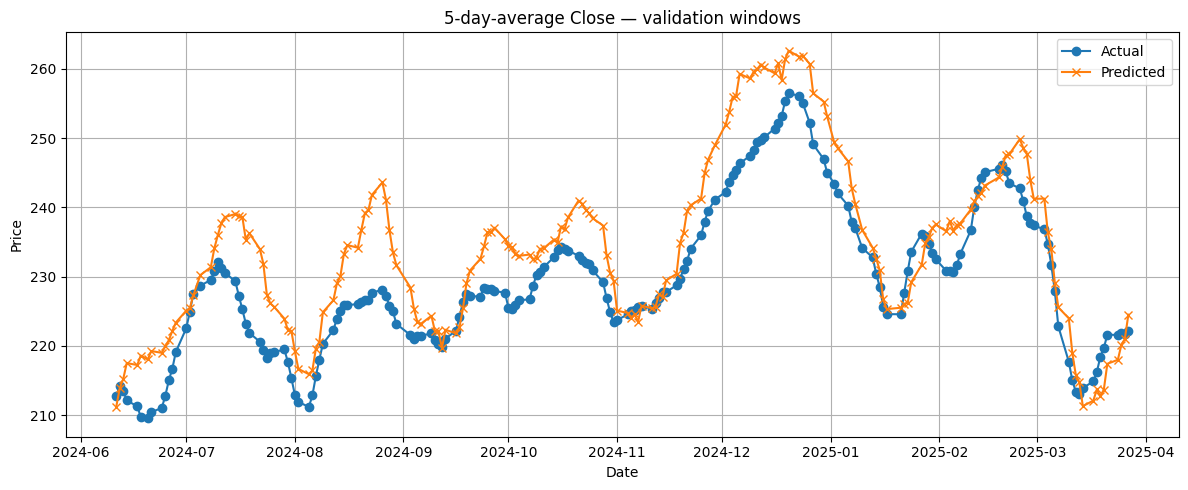

In [12]:
def directional_accuracy(y, yhat):
    return np.mean(np.sign(np.diff(y)) == np.sign(np.diff(yhat)))

mae  = mean_absolute_error(true_closes, pred_closes)
rmse = math.sqrt(mean_squared_error(true_closes, pred_closes))
da   = directional_accuracy(true_closes, pred_closes)

print(f"\nValidation MAE  : {mae:.4f}")
print(f"Validation RMSE : {rmse:.4f}")
print(f"Directional Acc.: {da:.4f}")

plt.figure(figsize=(12,5))
plt.plot(dates, true_closes, label='Actual', marker='o')
plt.plot(dates, pred_closes, label='Predicted', marker='x')
plt.title('5‑day‑average Close — validation windows')
plt.xlabel('Date'); plt.ylabel('Price'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### Comparisons with the Baseline Models

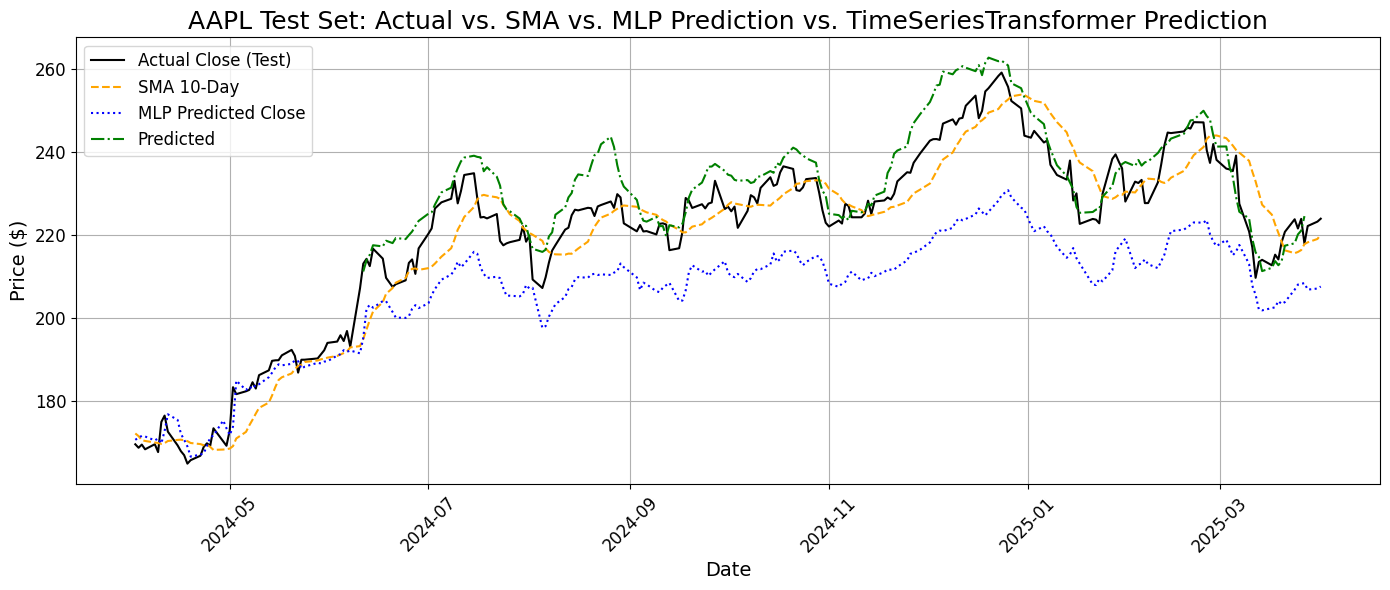

In [13]:
date_index_valid = aapl['Date'].iloc[1:-1].reset_index(drop=True)

test_dates = date_index_valid[-len(y_test):]
sma_test = sma_aapl_eval['SMA10'].iloc[-len(test_dates):].reset_index(drop=True)



plt.figure(figsize=(14, 6))

plt.plot(test_dates, y_test_true_np, label='Actual Close (Test)', color='black')

# Plot SMA baseline (aligned with test period)
plt.plot(test_dates, sma_test, label='SMA 10-Day', color='orange', linestyle='--')

# Plot MLP predictions
plt.plot(test_dates, y_test_pred_np, label='MLP Predicted Close', color='blue', linestyle='dotted')

# Plot TimeSeriesTransformer predictions
plt.plot(dates, pred_closes, label='Predicted', color='green', linestyle = 'dashdot')

# Plot formatting with larger fonts
plt.title('AAPL Test Set: Actual vs. SMA vs. MLP Prediction vs. TimeSeriesTransformer Prediction', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()